<a href="https://colab.research.google.com/github/JayaHore/Travel_medium-_prediction/blob/main/travel_medium_prediction_optimized_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:

# Install and Import
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

def split_dataset(input_csv, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Split dataset into train, validation, and test sets.

    Args:
        input_csv: Path to merged CSV file
        train_ratio: Proportion for training (default: 0.7 = 70%)
        val_ratio: Proportion for validation (default: 0.15 = 15%)
        test_ratio: Proportion for testing (default: 0.15 = 15%)
        random_state: Random seed for reproducibility
    """

    # Verify ratios sum to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.001, "Ratios must sum to 1.0"

    # Load the data
    print(f"Loading data from: {input_csv}")
    df = pd.read_csv(input_csv)

    # Handle potential NaN values in the 'label' column before splitting
    initial_rows = len(df)
    df.dropna(subset=['label'], inplace=True)
    if len(df) < initial_rows:
        print(f"Warning: Dropped {initial_rows - len(df)} rows due to NaN values in 'label' column.")

    print(f"Total records: {len(df)}")
    print(f"\nLabel distribution in full dataset:")
    print(df['label'].value_counts())
    print(f"\n{'='*50}")

    # First split: separate train from (val + test)
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_ratio),
        random_state=random_state,
        stratify=df['label']  # Maintain label distribution
    )

    # Second split: separate val from test
    # Calculate the proportion of val in the temp set
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_adjusted),
        random_state=random_state,
        stratify=temp_df['label']
    )

    # Save the splits
    train_file = input_csv.replace('.csv', '_train.csv')
    val_file = input_csv.replace('.csv', '_val.csv')
    test_file = input_csv.replace('.csv', '_test.csv')

    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)

    # Print statistics
    print(f"✓ Training set: {len(train_df)} records ({train_ratio*100:.1f}%)")
    print(f"  Saved to: {train_file}")
    print(f"  Label distribution:")
    print(f"  {train_df['label'].value_counts().to_dict()}\n")

    print(f"✓ Validation set: {len(val_df)} records ({val_ratio*100:.1f}%)")
    print(f"  Saved to: {val_file}")
    print(f"  Label distribution:")
    print(f"  {val_df['label'].value_counts().to_dict()}\n")

    print(f"✓ Test set: {len(test_df)} records ({test_ratio*100:.1f}%)")
    print(f"  Saved to: {test_file}")
    print(f"  Label distribution:")
    print(f"  {test_df['label'].value_counts().to_dict()}\n")

    print(f"{'='*50}")
    print(f"✓ Dataset split completed!")

    return train_df, val_df, test_df

# Usage - Standard 70/15/15 split
input_file = "/content/sensor_data_merged.csv"
train_df, val_df, test_df = split_dataset(input_file)

Loading data from: /content/sensor_data_merged.csv
Total records: 1143833

Label distribution in full dataset:
label
bus      465265
auto     214357
train    123367
van      106529
cycle    105007
toto      75948
bike      53360
Name: count, dtype: int64

✓ Training set: 800683 records (70.0%)
  Saved to: /content/sensor_data_merged_train.csv
  Label distribution:
  {'bus': 325685, 'auto': 150050, 'train': 86357, 'van': 74570, 'cycle': 73505, 'toto': 53164, 'bike': 37352}

✓ Validation set: 171575 records (15.0%)
  Saved to: /content/sensor_data_merged_val.csv
  Label distribution:
  {'bus': 69790, 'auto': 32154, 'train': 18505, 'van': 15979, 'cycle': 15751, 'toto': 11392, 'bike': 8004}

✓ Test set: 171575 records (15.0%)
  Saved to: /content/sensor_data_merged_test.csv
  Label distribution:
  {'bus': 69790, 'auto': 32153, 'train': 18505, 'van': 15980, 'cycle': 15751, 'toto': 11392, 'bike': 8004}

✓ Dataset split completed!


In [11]:
def create_balanced_dataset(csv_file, output_file, strategy='hybrid', target_samples_per_class=50000):
    """
    Create a balanced dataset using hybrid approach.

    Args:
        csv_file: Input CSV file
        output_file: Output balanced CSV file
        strategy: 'undersample', 'oversample', or 'hybrid'
        target_samples_per_class: Target number of samples per class for hybrid
    """
    df = pd.read_csv(csv_file)

    print(f"\n📊 Original distribution for {csv_file.split('/')[-1]}:")
    original_dist = df['label'].value_counts()
    print(original_dist)
    print(f"Total samples: {len(df)}")

    if strategy == 'undersample':
        # Undersample to smallest class
        min_size = df['label'].value_counts().min()
        balanced_dfs = []
        for label in df['label'].unique():
            label_df = df[df['label'] == label]
            sampled_df = label_df.sample(n=min(len(label_df), min_size), random_state=42)
            balanced_dfs.append(sampled_df)
        balanced_df = pd.concat(balanced_dfs, ignore_index=True)

    elif strategy == 'oversample':
        # Oversample using SMOTE-like duplication
        max_size = df['label'].value_counts().max()
        balanced_dfs = []
        for label in df['label'].unique():
            label_df = df[df['label'] == label]
            if len(label_df) < max_size:
                # Oversample with replacement
                sampled_df = label_df.sample(n=max_size, random_state=42, replace=True)
            else:
                sampled_df = label_df
            balanced_dfs.append(sampled_df)
        balanced_df = pd.concat(balanced_dfs, ignore_index=True)

    elif strategy == 'hybrid':
        # Hybrid: undersample majority, oversample minority to target
        balanced_dfs = []
        for label in df['label'].unique():
            label_df = df[df['label'] == label]
            current_size = len(label_df)

            if current_size > target_samples_per_class:
                # Undersample
                sampled_df = label_df.sample(n=target_samples_per_class, random_state=42)
            elif current_size < target_samples_per_class:
                # Oversample
                sampled_df = label_df.sample(n=target_samples_per_class, random_state=42, replace=True)
            else:
                sampled_df = label_df

            balanced_dfs.append(sampled_df)
        balanced_df = pd.concat(balanced_dfs, ignore_index=True)

    # Shuffle
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Save
    balanced_df.to_csv(output_file, index=False)

    print(f"\n📊 Balanced distribution:")
    print(balanced_df['label'].value_counts())
    print(f"Total samples: {len(balanced_df)}")
    print(f"✓ Saved to: {output_file}\n")

    return balanced_df


# Create balanced datasets
print("="*60)
print("CREATING BALANCED DATASETS")
print("="*60)

balanced_train = create_balanced_dataset(
    "/content/sensor_data_merged_train.csv",
    "/content/sensor_data_balanced_train.csv",
    strategy='hybrid',
    target_samples_per_class=50000  # Adjust based on your needs
)

balanced_val = create_balanced_dataset(
    "/content/sensor_data_merged_val.csv",
    "/content/sensor_data_balanced_val.csv",
    strategy='hybrid',
    target_samples_per_class=10000
)

balanced_test = create_balanced_dataset(
    "/content/sensor_data_merged_test.csv",
    "/content/sensor_data_balanced_test.csv",
    strategy='hybrid',
    target_samples_per_class=10000
)

CREATING BALANCED DATASETS

📊 Original distribution for sensor_data_merged_train.csv:
label
bus      325685
auto     150050
train     86357
van       74570
cycle     73505
toto      53164
bike      37352
Name: count, dtype: int64
Total samples: 800683

📊 Balanced distribution:
label
van      50000
cycle    50000
bike     50000
toto     50000
train    50000
bus      50000
auto     50000
Name: count, dtype: int64
Total samples: 350000
✓ Saved to: /content/sensor_data_balanced_train.csv


📊 Original distribution for sensor_data_merged_val.csv:
label
bus      69790
auto     32154
train    18505
van      15979
cycle    15751
toto     11392
bike      8004
Name: count, dtype: int64
Total samples: 171575

📊 Balanced distribution:
label
cycle    10000
train    10000
auto     10000
toto     10000
bus      10000
van      10000
bike     10000
Name: count, dtype: int64
Total samples: 70000
✓ Saved to: /content/sensor_data_balanced_val.csv


📊 Original distribution for sensor_data_merged_test.csv:
l

In [12]:
class IMUDataset(Dataset):
    """Optimized Dataset class for IMU sensor data."""

    def __init__(self, csv_file, window_size=128, stride=64, label_encoder=None, augment=False):
        """
        Args:
            csv_file: Path to CSV file
            window_size: Number of timesteps in each window
            stride: Stride for sliding window
            label_encoder: LabelEncoder for labels
            augment: Whether to apply data augmentation
        """
        self.data = pd.read_csv(csv_file)
        self.window_size = window_size
        self.stride = stride
        self.augment = augment

        # Feature columns
        self.feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

        # Encode labels
        if label_encoder is None:
            self.label_encoder = LabelEncoder()
            self.labels_encoded = self.label_encoder.fit_transform(self.data['label'])
        else:
            self.label_encoder = label_encoder
            self.labels_encoded = self.label_encoder.transform(self.data['label'])

        # Create windows
        self.windows, self.window_labels = self._create_windows()

        print(f"Dataset: {len(self.windows)} windows from {csv_file.split('/')[-1]}")
        print(f"Classes: {self.label_encoder.classes_}")
        print(f"Window size: {window_size}, Stride: {stride}, Augment: {augment}")

    def _create_windows(self):
        """Create sliding windows from the data."""
        windows = []
        labels = []

        sensor_data = self.data[self.feature_cols].values

        for i in range(0, len(sensor_data) - self.window_size + 1, self.stride):
            window = sensor_data[i:i + self.window_size]
            window_labels_slice = self.labels_encoded[i:i + self.window_size]
            label = np.bincount(window_labels_slice).argmax()

            windows.append(window)
            labels.append(label)

        return np.array(windows, dtype=np.float32), np.array(labels, dtype=np.int64)

    def _augment_window(self, window):
        """Apply data augmentation to a window."""
        if np.random.rand() < 0.5:
            # Add Gaussian noise
            noise = np.random.normal(0, 0.01, window.shape)
            window = window + noise

        if np.random.rand() < 0.3:
            # Scale
            scale = np.random.uniform(0.9, 1.1)
            window = window * scale

        return window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        window = self.windows[idx].copy()

        if self.augment:
            window = self._augment_window(window)

        return torch.FloatTensor(window), torch.LongTensor([self.window_labels[idx]])[0]

In [13]:
class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class LabelSmoothingCrossEntropy(nn.Module):
    """Label Smoothing to prevent overconfidence."""

    def __init__(self, epsilon=0.1, weight=None):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.weight = weight

    def forward(self, preds, target):
        n_classes = preds.size(-1)
        log_preds = nn.functional.log_softmax(preds, dim=-1)

        # One-hot encode targets
        targets_one_hot = torch.zeros_like(preds).scatter_(1, target.unsqueeze(1), 1)

        # Apply label smoothing
        targets_smooth = (1 - self.epsilon) * targets_one_hot + self.epsilon / n_classes

        loss = -(targets_smooth * log_preds).sum(dim=-1)

        if self.weight is not None:
            loss = loss * self.weight[target]

        return loss.mean()

In [14]:
class PositionalEncoding(nn.Module):
    """Positional encoding for transformer."""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class IMUTransformer(nn.Module):
    """Enhanced Transformer model for IMU-based activity recognition."""

    def __init__(self, input_dim=6, d_model=128, nhead=8, num_layers=4,
                 dim_feedforward=512, num_classes=7, dropout=0.3):
        super(IMUTransformer, self).__init__()

        # Input projection with batch norm
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True  # Pre-LN architecture
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Classification head with deeper network
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Project input
        x = self.input_projection(x)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer encoding
        x = self.transformer_encoder(x)

        # Global average pooling
        x = torch.mean(x, dim=1)

        # Classification
        x = self.classifier(x)

        return x

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device, use_mixup=False, alpha=0.2):
    """Train for one epoch with optional mixup."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Mixup augmentation
        if use_mixup and np.random.rand() < 0.5:
            lam = np.random.beta(alpha, alpha)
            batch_size = inputs.size(0)
            index = torch.randperm(batch_size).to(device)

            mixed_inputs = lam * inputs + (1 - lam) * inputs[index]
            labels_a, labels_b = labels, labels[index]

            optimizer.zero_grad()
            outputs = model(mixed_inputs)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """Evaluate the model."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


def plot_confusion_matrix(y_true, y_pred, classes, save_path='confusion_matrix.png'):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax1)
    ax1.set_title('Confusion Matrix (Counts)')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')

    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=ax2)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Confusion matrix saved to {save_path}")


def plot_training_history(train_losses, val_losses, train_accs, val_accs,
                          train_f1s, val_f1s, save_path='training_history.png'):
    """Plot training history."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Loss
    axes[0].plot(train_losses, label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(val_losses, label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(train_accs, label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(val_accs, label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # F1 Score
    axes[2].plot(train_f1s, label='Train F1', marker='o', linewidth=2)
    axes[2].plot(val_f1s, label='Val F1', marker='s', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score (Macro)', fontsize=12)
    axes[2].set_title('Training and Validation F1 Score', fontsize=14)
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Training history saved to {save_path}")

OPTIMIZED TRAVEL MEDIUM DETECTION

📊 Loading datasets...
Dataset: 5467 windows from sensor_data_balanced_train.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: True
Dataset: 1092 windows from sensor_data_balanced_val.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False


/tmp/ipykernel_600/2274892384.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)


Dataset: 1092 windows from sensor_data_balanced_test.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False

✓ Number of classes: 7
✓ Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']

📊 Training set window distribution:
  auto: 880 (16.10%)
  bike: 822 (15.04%)
  bus: 854 (15.62%)
  cycle: 758 (13.87%)
  toto: 723 (13.22%)
  train: 721 (13.19%)
  van: 709 (12.97%)

⚖️ Computing class weights...
Class weights:
  auto: 0.8875
  bike: 0.9501
  bus: 0.9145
  cycle: 1.0303
  toto: 1.0802
  train: 1.0832
  van: 1.1016

⚖️ Using weighted random sampler...

🤖 Creating model...
✓ Total parameters: 5,007,111
✓ Trainable parameters: 5,007,111

🎯 Using Focal Loss

🚀 Starting training...

Epoch [1/100]


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 13.68it/s]



🏆 Best model saved!
   Val F1: 0.0304 | Val Acc: 0.1190

📊 Epoch Results:
   Train Loss: 1.4971 | Train Acc: 0.1432 | Train F1: 0.0358
   Val Loss: 1.4431   | Val Acc: 0.1190   | Val F1: 0.0304

🏆 Best:
   Best Val F1: 0.0304 | Best Val Acc: 0.1190

⚙️ Training Info:
   LR: 0.000488 | Patience: 0/20

Epoch [2/100]


...


📊 Epoch Results:
   Train Loss: 1.3789 | Train Acc: 0.2001 | Train F1: 0.1140
   Val Loss: 1.4375   | Val Acc: 0.1612   | Val F1: 0.0988

🏆 Best:
   Best Val F1: 0.1371 | Best Val Acc: 0.1923

⚙️ Training Info:
   LR: 0.000211 | Patience: 18/20

Epoch [53/100]


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 13.86it/s]



📊 Epoch Results:
   Train Loss: 1.3802 | Train Acc: 0.1913 | Train F1: 0.1254
   Val Loss: 1.4095   | Val Acc: 0.1758   | Val F1: 0.1094

🏆 Best:
   Best Val F1: 0.1371 | Best Val Acc: 0.1923

⚙️ Training Info:
   LR: 0.000192 | Patience: 19/20

Epoch [54/100]


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 13.96it/s]



📊 Epoch Results:
   Train Loss: 1.3773 | Train Acc: 0.1882 | Train F1: 0.1167
   Val Loss: 1.4402   | Val Acc: 0.1658   | Val F1: 0.1008

🏆 Best:
   Best Val F1: 0.1371 | Best Val Acc: 0.1923

⚙️ Training Info:
   LR: 0.000173 | Patience: 20/20

⚠️ Early stopping triggered at epoch 54

✅ Training completed!


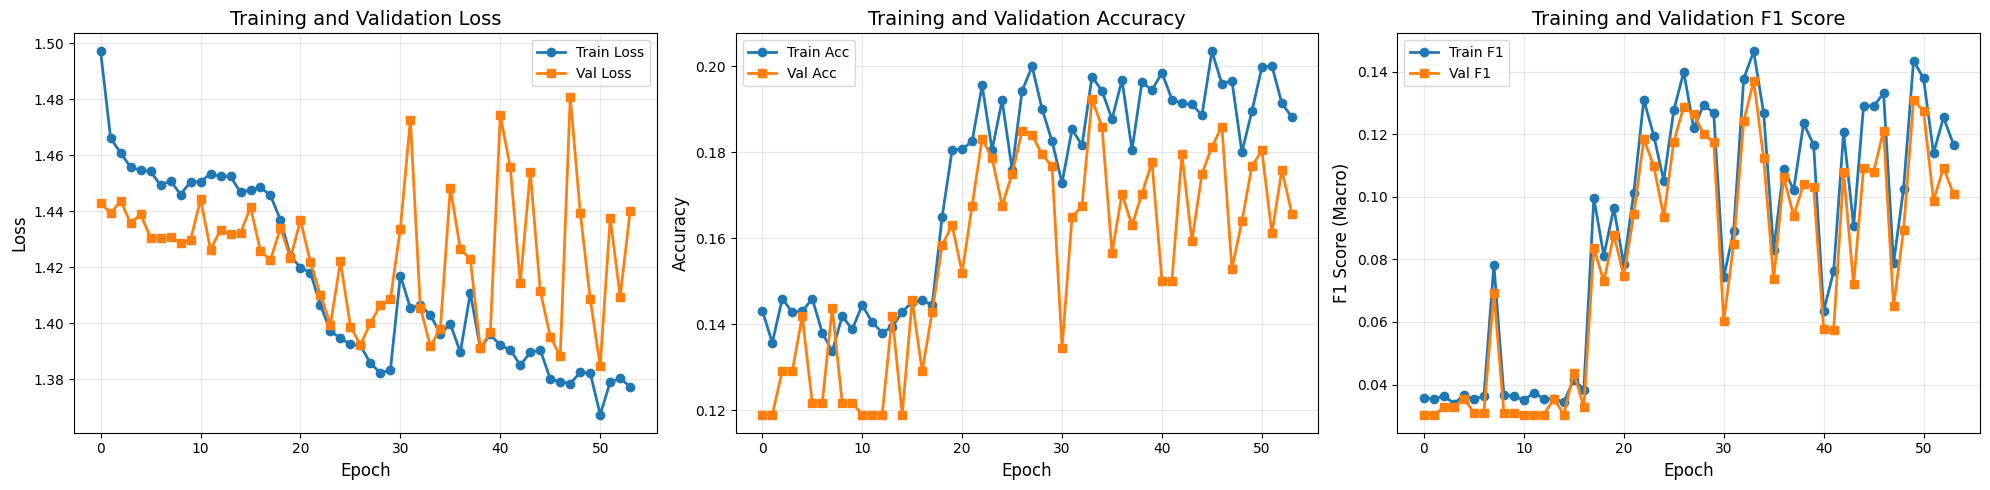

✓ Training history saved to /content/training_history_optimized.png

📊 Evaluating on test set...


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 12.57it/s]



FINAL TEST RESULTS
Test Loss: 1.3997
Test Accuracy: 0.1923
Test F1 (Macro): 0.1357
Test F1 (Weighted): 0.1282

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        auto     0.0000    0.0000    0.0000       180
        bike     0.0000    0.0000    0.0000       167
         bus     0.0000    0.0000    0.0000       154
       cycle     0.2296    0.5278    0.3200       144
        toto     0.1476    0.3161    0.2012       155
       train     0.2274    0.4626    0.3049       147
         van     0.1308    0.1172    0.1236       145

    accuracy                         0.1923      1092
   macro avg     0.1051    0.2034    0.1357      1092
weighted avg     0.0992    0.1923    0.1282      1092



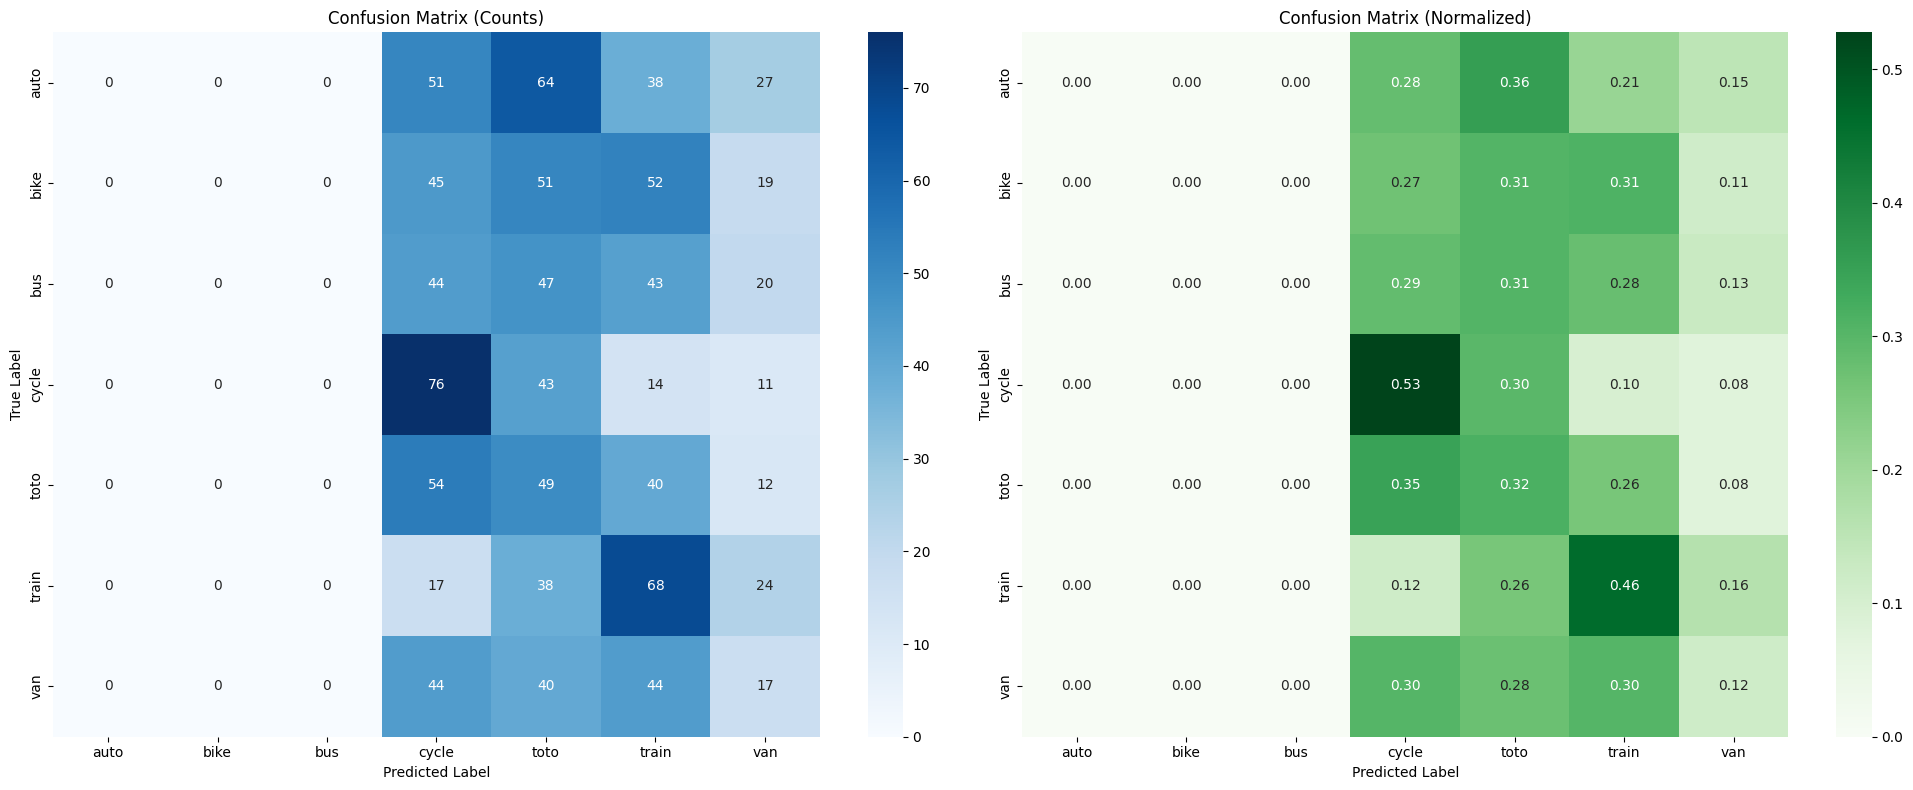

✓ Confusion matrix saved to /content/confusion_matrix_optimized.png

PER-CLASS METRICS
  auto     | Acc: 0.0000 | F1: 0.0000 | Support:   180
  bike     | Acc: 0.0000 | F1: 0.0000 | Support:   167
  bus      | Acc: 0.0000 | F1: 0.0000 | Support:   154
  cycle    | Acc: 0.5278 | F1: 0.3200 | Support:   144
  toto     | Acc: 0.3161 | F1: 0.2012 | Support:   155
  train    | Acc: 0.4626 | F1: 0.3049 | Support:   147
  van      | Acc: 0.1172 | F1: 0.1236 | Support:   145



In [16]:
def main_optimized():
    """Optimized main training pipeline."""

    # ============================================
    # HYPERPARAMETERS
    # ============================================
    WINDOW_SIZE = 128  # Increased for better context
    STRIDE = 64
    BATCH_SIZE = 128  # Increased batch size
    NUM_EPOCHS = 100
    LEARNING_RATE = 0.0005  # Lower learning rate
    WEIGHT_DECAY = 1e-4

    # Model hyperparameters
    D_MODEL = 256  # Increased model capacity
    NHEAD = 8
    NUM_LAYERS = 6  # Deeper network
    DIM_FEEDFORWARD = 1024
    DROPOUT = 0.3

    # Training strategies
    USE_FOCAL_LOSS = True
    USE_LABEL_SMOOTHING = False
    USE_MIXUP = True
    USE_WEIGHTED_SAMPLER = True

    # File paths - USING BALANCED DATASETS
    TRAIN_CSV = "/content/sensor_data_balanced_train.csv"
    VAL_CSV = "/content/sensor_data_balanced_val.csv"
    TEST_CSV = "/content/sensor_data_balanced_test.csv"

    print("="*60)
    print("OPTIMIZED TRAVEL MEDIUM DETECTION")
    print("="*60)

    # ============================================
    # LOAD DATASETS
    # ============================================
    print("\n📊 Loading datasets...")
    train_dataset = IMUDataset(TRAIN_CSV, window_size=WINDOW_SIZE, stride=STRIDE, augment=True)
    val_dataset = IMUDataset(VAL_CSV, window_size=WINDOW_SIZE, stride=STRIDE,
                              label_encoder=train_dataset.label_encoder, augment=False)
    test_dataset = IMUDataset(TEST_CSV, window_size=WINDOW_SIZE, stride=STRIDE,
                               label_encoder=train_dataset.label_encoder, augment=False)

    num_classes = len(train_dataset.label_encoder.classes_)
    print(f"\n✓ Number of classes: {num_classes}")
    print(f"✓ Classes: {train_dataset.label_encoder.classes_}")

    # Class distribution
    print("\n📊 Training set window distribution:")
    unique, counts = np.unique(train_dataset.window_labels, return_counts=True)
    for idx, count in zip(unique, counts):
        class_name = train_dataset.label_encoder.inverse_transform([idx])[0]
        print(f"  {class_name}: {count:,} ({count/len(train_dataset)*100:.2f}%)")

    # ============================================
    # COMPUTE CLASS WEIGHTS
    # ============================================
    print("\n⚖️ Computing class weights...")
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_dataset.window_labels),
        y=train_dataset.window_labels
    )
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    print("Class weights:")
    for idx, weight in enumerate(class_weights):
        class_name = train_dataset.label_encoder.inverse_transform([idx])[0]
        print(f"  {class_name}: {weight:.4f}")

    # ============================================
    # CREATE DATALOADERS
    # ============================================
    if USE_WEIGHTED_SAMPLER:
        print("\n⚖️ Using weighted random sampler...")
        sample_weights = class_weights[train_dataset.window_labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # ============================================
    # CREATE MODEL
    # ============================================
    print("\n🤖 Creating model...")
    model = IMUTransformer(
        input_dim=6,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        num_classes=num_classes,
        dropout=DROPOUT
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✓ Total parameters: {total_params:,}")
    print(f"✓ Trainable parameters: {trainable_params:,}")

    # ============================================
    # LOSS FUNCTION
    # ============================================
    if USE_FOCAL_LOSS:
        print("\n🎯 Using Focal Loss")
        criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
    elif USE_LABEL_SMOOTHING:
        print("\n🎯 Using Label Smoothing Cross Entropy")
        criterion = LabelSmoothingCrossEntropy(epsilon=0.1, weight=class_weights_tensor)
    else:
        print("\n🎯 Using Weighted Cross Entropy")
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # ============================================
    # OPTIMIZER AND SCHEDULER
    # ============================================
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Cosine annealing with warm restarts
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # ============================================
    # TRAINING LOOP
    # ============================================
    print("\n🚀 Starting training...")
    print("="*60)

    best_val_f1 = 0.0
    best_val_acc = 0.0
    patience_counter = 0
    early_stop_patience = 20

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    for epoch in range(NUM_EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        print(f"{'='*60}")

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device,
            use_mixup=USE_MIXUP
        )

        # Calculate train F1
        model.eval()
        train_preds_all = []
        train_labels_all = []
        with torch.no_grad():
            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                train_preds_all.extend(preds.cpu().numpy())
                train_labels_all.extend(labels.numpy())
        train_f1 = f1_score(train_labels_all, train_preds_all, average='macro')

        # Validate
        val_loss, val_acc, val_preds, val_labels, _ = evaluate(model, val_loader, criterion, device)
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        # Step scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            patience_counter = 0

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
                'model_config': {
                    'input_dim': 6,
                    'd_model': D_MODEL,
                    'nhead': NHEAD,
                    'num_layers': NUM_LAYERS,
                    'dim_feedforward': DIM_FEEDFORWARD,
                    'num_classes': num_classes,
                    'dropout': DROPOUT
                },
                'window_size': WINDOW_SIZE
            }, '/content/best_model_optimized.pth')

            with open('/content/label_encoder.pkl', 'wb') as f:
                pickle.dump(train_dataset.label_encoder, f)

            print(f"\n🏆 Best model saved!")
            print(f"   Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1

        # Record history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        # Print statistics
        print(f"\n📊 Epoch Results:")
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
        print(f"   Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.4f}   | Val F1: {val_f1:.4f}")
        print(f"\n🏆 Best:")
        print(f"   Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}")
        print(f"\n⚙️ Training Info:")
        print(f"   LR: {current_lr:.6f} | Patience: {patience_counter}/{early_stop_patience}")

        # Early stopping
        if patience_counter >= early_stop_patience:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            break

    print("\n" + "="*60)
    print("✅ Training completed!")
    print("="*60)

    # ============================================
    # PLOT TRAINING HISTORY
    # ============================================
    plot_training_history(
        train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s,
        '/content/training_history_optimized.png'
    )

    # ============================================
    # TEST EVALUATION
    # ============================================
    print("\n📊 Evaluating on test set...")
    checkpoint = torch.load('/content/best_model_optimized.pth', weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])

    test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
        model, test_loader, criterion, device
    )

    # Calculate metrics
    test_f1_macro = f1_score(test_labels, test_preds, average='macro')
    test_f1_weighted = f1_score(test_labels, test_preds, average='weighted')

    print(f"\n{'='*60}")
    print(f"FINAL TEST RESULTS")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1 (Macro): {test_f1_macro:.4f}")
    print(f"Test F1 (Weighted): {test_f1_weighted:.4f}")

    # Classification report
    print(f"\n{'='*60}")
    print("DETAILED CLASSIFICATION REPORT")
    print(f"{'='*60}")
    print(classification_report(
        test_labels, test_preds,
        target_names=train_dataset.label_encoder.classes_,
        digits=4,
        zero_division=0
    ))

    # Confusion matrix
    plot_confusion_matrix(
        test_labels, test_preds,
        train_dataset.label_encoder.classes_,
        '/content/confusion_matrix_optimized.png'
    )

    # Per-class accuracy
    print(f"\n{'='*60}")
    print("PER-CLASS METRICS")
    print(f"{'='*60}")
    cm = confusion_matrix(test_labels, test_preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    for idx, acc in enumerate(per_class_acc):
        class_name = train_dataset.label_encoder.classes_[idx]
        class_f1 = f1_score(test_labels, test_preds, labels=[idx], average='macro')
        support = cm.sum(axis=1)[idx]
        print(f"  {class_name:8s} | Acc: {acc:.4f} | F1: {class_f1:.4f} | Support: {support:5d}")

    print(f"{'='*60}\n")

    return model, train_dataset.label_encoder


# ============================================
# RUN TRAINING
# ============================================
model, label_encoder = main_optimized()

In [17]:
def predict_travel_medium(model, label_encoder, sensor_data, window_size=128, device='cpu'):
    """Predict travel medium with confidence scores."""
    model.eval()

    if len(sensor_data) < window_size:
        padding = np.zeros((window_size - len(sensor_data), 6))
        sensor_data = np.vstack([sensor_data, padding])

    window = sensor_data[-window_size:]
    window_tensor = torch.FloatTensor(window).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(window_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = label_encoder.inverse_transform([predicted.cpu().item()])[0]
    confidence = confidence.cpu().item()
    all_probs = probabilities.cpu().numpy()[0]

    # Get top 3 predictions
    top3_indices = np.argsort(all_probs)[::-1][:3]
    top3_classes = label_encoder.inverse_transform(top3_indices)
    top3_probs = all_probs[top3_indices]

    return predicted_class, confidence, list(zip(top3_classes, top3_probs))


# Example prediction
print("\n🔮 Example Predictions:")
print("="*60)

test_data = pd.read_csv("/content/sensor_data_balanced_test.csv")
sample_data = test_data[['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']].values[:128]
actual_label = test_data['label'].values[0]

predicted, confidence, top3 = predict_travel_medium(model, label_encoder, sample_data, device=device)

print(f"Actual: {actual_label}")
print(f"Predicted: {predicted} (Confidence: {confidence:.4f})")
print(f"\nTop 3 Predictions:")
for cls, prob in top3:
    print(f"  {cls}: {prob:.4f}")
print("="*60)


# Save complete model
print("\n💾 Saving model...")
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_dim': 6,
        'd_model': 256,
        'nhead': 8,
        'num_layers': 6,
        'dim_feedforward': 1024,
        'num_classes': len(label_encoder.classes_),
        'dropout': 0.3
    },
    'window_size': 128,
    'classes': label_encoder.classes_.tolist()
}, '/content/final_model_complete.pth')

with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✓ Model saved to: /content/final_model_complete.pth")
print("✓ Label encoder saved to: /content/label_encoder.pkl")

# Download files
from google.colab import files
print("\n📥 Download files...")
files.download('/content/best_model_optimized.pth')
files.download('/content/final_model_complete.pth')
files.download('/content/label_encoder.pkl')
files.download('/content/training_history_optimized.png')
files.download('/content/confusion_matrix_optimized.png')

print("\n✅ All done!")


🔮 Example Predictions:
Actual: auto
Predicted: cycle (Confidence: 0.2206)

Top 3 Predictions:
  cycle: 0.2206
  toto: 0.2023
  van: 0.1591

💾 Saving model...
✓ Model saved to: /content/final_model_complete.pth
✓ Label encoder saved to: /content/label_encoder.pkl

📥 Download files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done!
